#T13.


In [28]:
from scipy.stats import f
import numpy as np
import matplotlib.pyplot as plt

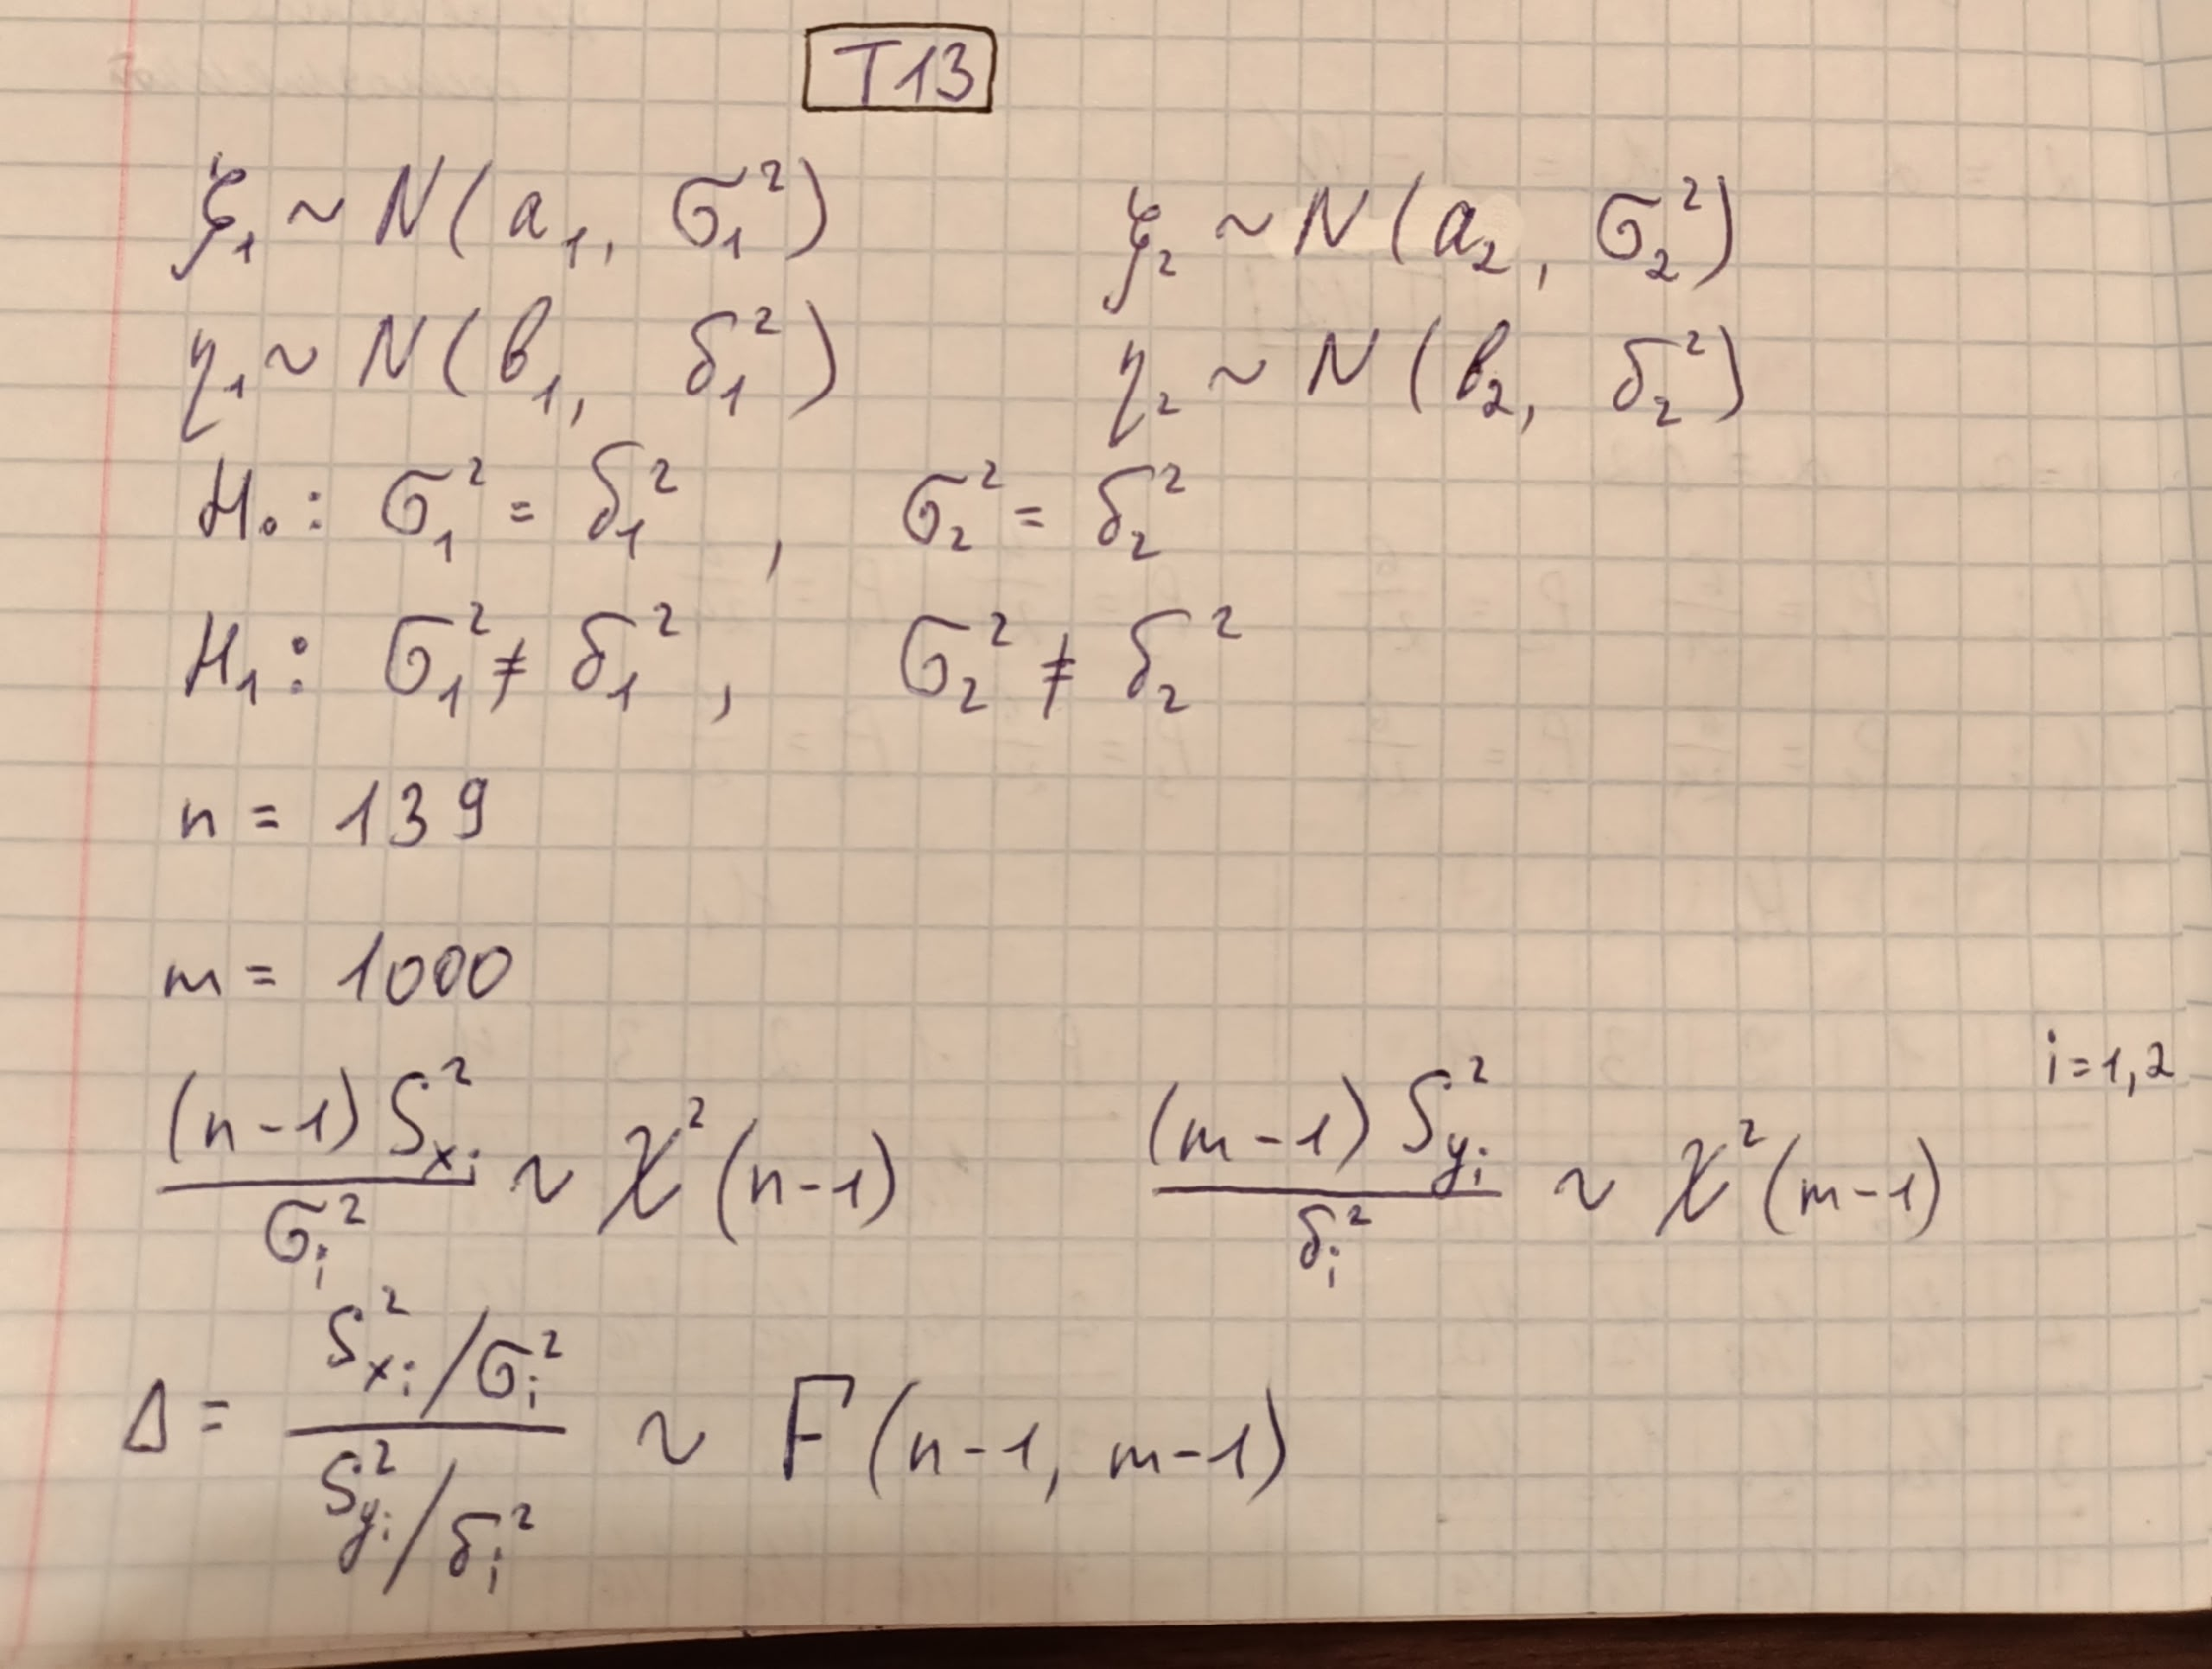

In [29]:
#Значения
n = 139
std_lenght_1 = 5.722
std_width_1 = 4.612
m = 1000
std_lenght_2 = 6.161
std_width_2 = 5.055

delta_length = std_lenght_1**2 / std_lenght_2**2
delta_width = std_width_1**2 / std_width_2**2

# Уровень значимости
alpha = 0.05

# Критические значения
f_lower = f.ppf(alpha / 2, n - 1, m - 1)
f_upper = f.ppf(1 - alpha / 2, n - 1, m - 1)

print(f"F (ширина): {delta_length}")
print(f"F (длина) {delta_width}")
print(f"Квантили для F: [{f_lower}, {f_upper}]")

F (ширина): 0.8625678945904338
F (длина) 0.8324080612765026
Квантили для F: [0.7673823155977318, 1.2716970730369903]


Δ для длины и Δ для ширины попадают внутрь интервала между квантилями

In [30]:
p_value_length = f.sf(delta_length, n - 1, m - 1)
p_value_width = f.sf(delta_width, n - 1, m - 1)

print(f"P-value (Length): {p_value_length:.4f}")
print(f"P-value (Width): {p_value_width:.4f}")

P-value (Length): 0.8636
P-value (Width): 0.9134


$\alpha/2 \le p-value (длина) \le 1 - \alpha/2$
$ \alpha/2 \le p-value (ширина) \le 1 - \alpha/2$

Нет оснований отвергнуть $H_0$

###График мощности

$W = 1 - P(U_{\alpha/2} \le x \le U_{1 - \alpha/2})$

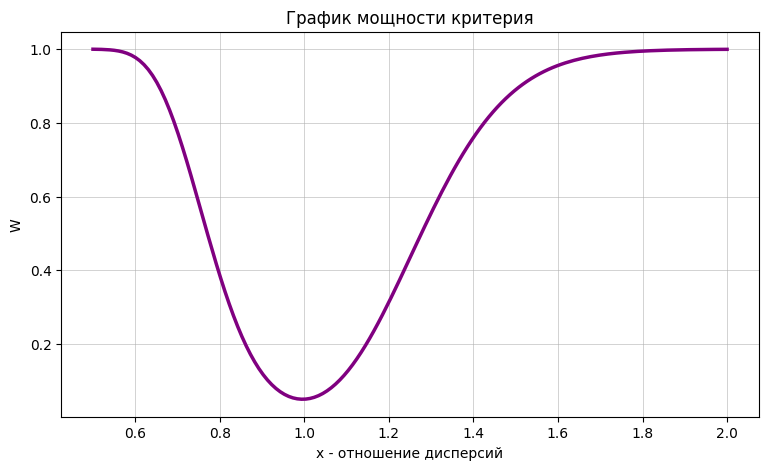

In [31]:
x = np.linspace(0.5, 2, 150)
power = 1 - f.cdf(f_upper, n - 1, m - 1, scale=x) + f.cdf(f_lower, n - 1, m - 1, scale=x)

plt.figure(figsize=(9, 5))
plt.plot(x, power, color="purple", linewidth=2.5)
plt.xlabel("x - отношение дисперсий")
plt.ylabel("W")
plt.title("График мощности критерия")
plt.grid(linewidth=0.4)
plt.show()